In [1]:
from src.parse.config import load_config
from src.dataset import get_image_detection_datas
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np

2026-03-29 15:16:27.172650: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-29 15:16:27.217099: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-03-29 15:16:27.243509: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8473] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-03-29 15:16:27.251528: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1471] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-03-29 15:16:27.286738: I tensorflow/core/platform/cpu_feature_guar

In [2]:
config = load_config(file_path="config/config.yml")

image_datas = get_image_detection_datas(dataset_path=config.dataset_path)

In [3]:
pair_counter = Counter(tuple(sorted(img.scores)) for img in image_datas)

In [4]:

# Counter for single die scores
single_score_counter = Counter()
for img in image_datas:
    single_score_counter.update(img.scores)


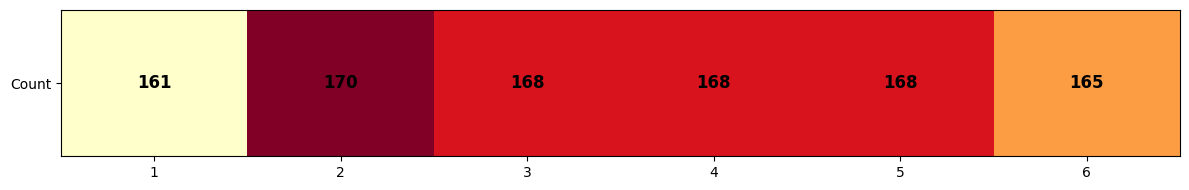

In [9]:

dice_scores = list(range(1, 7))
counts = [single_score_counter[score] for score in dice_scores]

# Create 1x6 matrix
single_matrix = np.array([counts])

# Create figure and axis
fig, ax = plt.subplots(figsize=(12, 2))

# Create heatmap
im = ax.imshow(single_matrix, cmap='YlOrRd', aspect='auto')

# Set ticks and labels
ax.set_xticks(np.arange(6))
ax.set_yticks([0])
ax.set_xticklabels([str(score) for score in dice_scores])
ax.set_yticklabels(['Count'])

# Add text annotations in cells
for j in range(6):
    text = ax.text(j, 0, f"{single_matrix[0, j]:.0f}",
                  ha="center", va="center", color="black", fontsize=12, weight='bold')

plt.tight_layout()
plt.show()


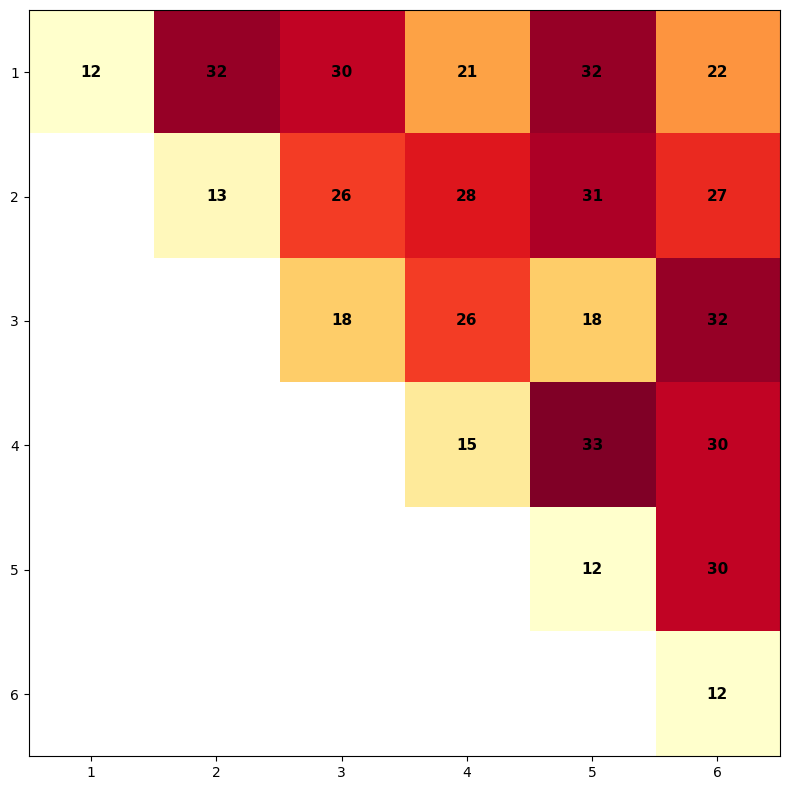

In [6]:
# Create a 6x6 matrix for dice scores (1-6)
matrix = np.zeros((6, 6))

# Fill the matrix with counts from score_counter
for (score1, score2), count in pair_counter.items():
    # Convert to 0-indexed
    i = min(score1, score2) - 1
    j = max(score1, score2) - 1
    matrix[i][j] = count

# Mask the lower triangle (set to NaN)
for i in range(6):
    for j in range(i):
        matrix[i][j] = np.nan

# Create figure and axis
fig, ax = plt.subplots(figsize=(8, 8))

# Create heatmap
im = ax.imshow(matrix, cmap='YlOrRd', aspect='auto')

# Set ticks and labels
dice_scores = ['1', '2', '3', '4', '5', '6']
ax.set_xticks(np.arange(6))
ax.set_yticks(np.arange(6))
ax.set_xticklabels(dice_scores)
ax.set_yticklabels(dice_scores)

# Add text annotations in cells (only upper triangle)
for i in range(6):
    for j in range(6):
        if i <= j:  # Only show upper triangle
            text = ax.text(j, i, f"{matrix[i, j]:.0f}",
                          ha="center", va="center", color="black", fontsize=11, weight='bold')

plt.tight_layout()
plt.show()